In [11]:
!pip install tensorflow scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import keras

In [13]:
model = keras.models.load_model('best-cnn-model.keras')
conv = model.layers[0]

In [14]:
conv.weights[0].shape # 가중치 w 3*3+1*32=288, 모델이 필터 크기 만큼 학습한 수

TensorShape([3, 3, 1, 32])

In [15]:
conv.weights[1].shape # # 편향 b 32개, 필터 갯수만큼 

TensorShape([32])

In [16]:
import numpy as np

In [17]:
conv_weights = conv.weights[0].numpy()

In [18]:
conv_weights.mean(), conv_weights.std() #평균, 표준편차

(np.float32(-0.040515475), np.float32(0.27222183))

In [19]:
#학습하지 않은 모델
no_train_model = keras.Sequential()
no_train_model.add(keras.layers.Input(shape=(28,28,1)))
no_train_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [20]:
#가중치를 가져옴
no_train_conv = no_train_model.layers[0]
no_train_weights = no_train_conv.weights[0].numpy()
no_train_weights.mean(), no_train_weights.std()
# 학습 전후 표준편차를 비교했을 댸 -> 표준편차가 학습 후 증가했다.
#학습 후 필터들이 여러 종류의 패턴을 감지할 수 있는 능력을 가지게 됐다.

(np.float32(-0.0030944285), np.float32(0.08375758))

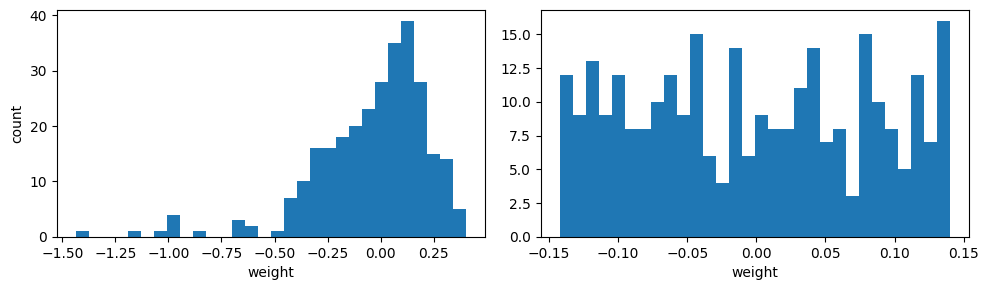

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(conv_weights.reshape(-1), bins=30)
axes[0].set_xlabel('weight'); axes[0].set_ylabel('count')

axes[1].hist(no_train_weights.reshape(-1), bins=30)
axes[1].set_xlabel('weight')

plt.tight_layout(); plt.show()

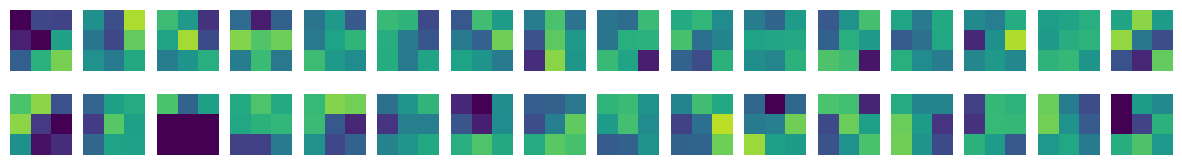

In [ ]:
#32개의 필터를 그리드로 출력(학습 후)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

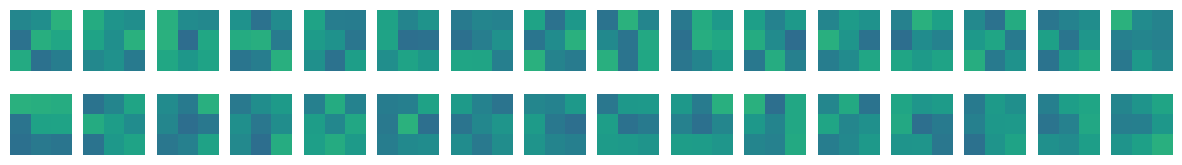

In [ ]:
#32개의 필터를 그리드로 출력(학습 전)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_train_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [ ]:
# 순차적 방식
keras.Sequential([
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])


# 함수형 API
inputs = keras.Input(shape=(784,))
dense1= keras.layers.Dense(100, activation='relu')
dense2= keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs) #함수 호출하듯이 통과 시킴
outputs = dense2(hidden) 

func_model = keras.Model(inputs, outputs) #입력 -> 출력으로 지정하여 모델 완성




<Functional name=functional_9, built=True>

In [28]:
model.inputs

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]

In [31]:
model.inputs[0], model.layers[0].output

(<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>,
 <KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor>)

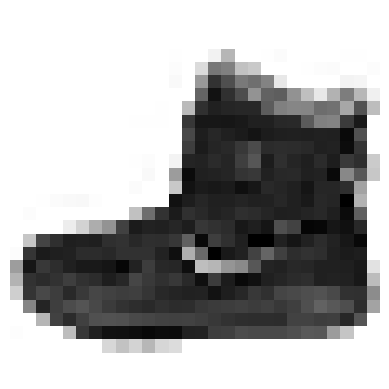

In [32]:
#특성 맵 비교
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

plt.imshow(train_input[0], cmap='gray_r')
plt.axis('off')
plt.show()

In [33]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1번째 층 출력 크기: (1, 28, 28, 32)


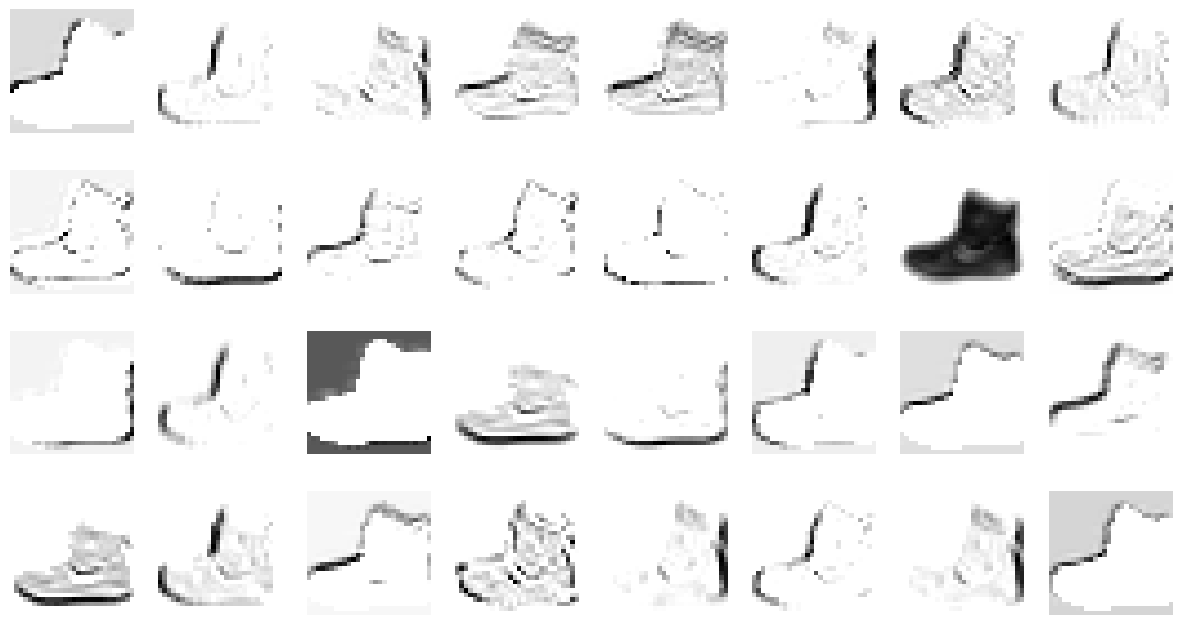

In [37]:
# 2. 첫 번째 Conv 층 활성화 모델 정의 및 예측

conv1_acti = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_maps1 = conv1_acti.predict(ankle_boot)

print("1번째 층 출력 크기:", feature_maps1.shape)
# 예상 출력: (1, 28, 28, 32)


# 3. 4행 8열, 총 32장의 feature map 출력

fig, axs = plt.subplots(4, 8, figsize=(15, 8))

for i in range(4):
    for j in range(8):
        axs[i, j].imshow(
            feature_maps1[0, :, :, i * 8 + j],
            cmap='gray_r'
        )
        axs[i, j].axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2번째 층 출력 크기: (1, 14, 14, 64)


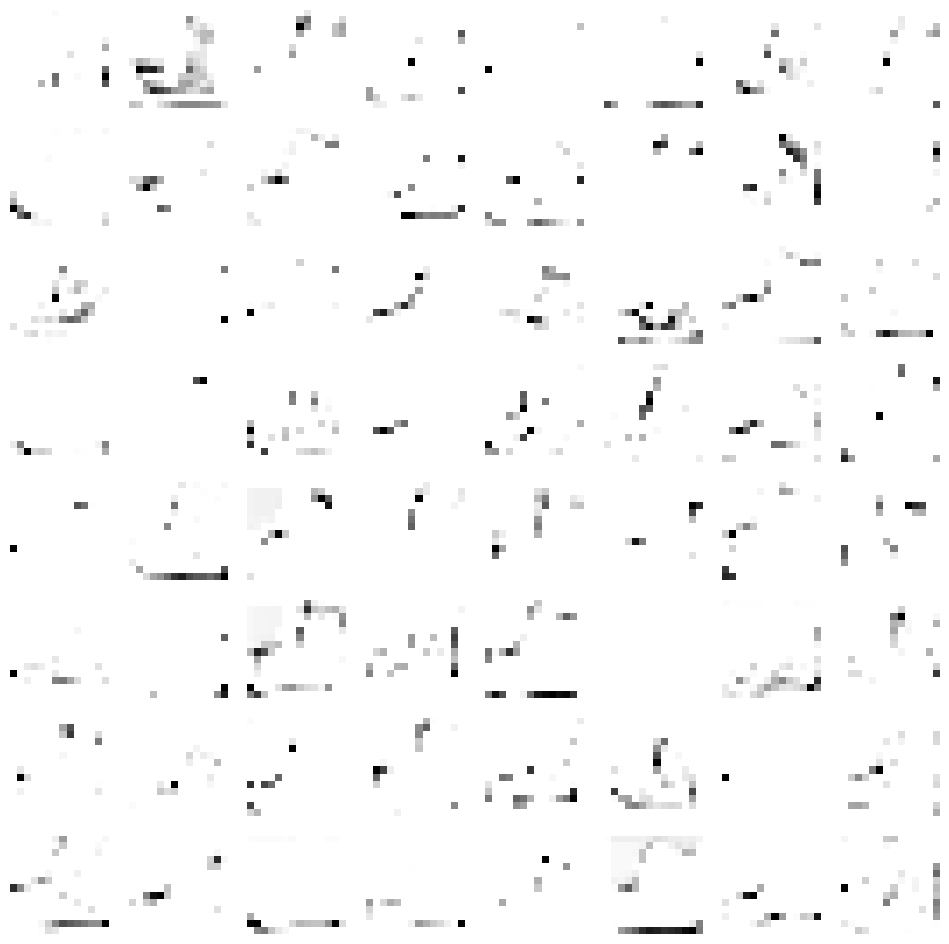

In [38]:
# 1. 2번째 Conv 층 활성화 모델 정의 및 예측 (인덱스 2번은 MaxPooling을 건너뛰기 위함)
conv2_acti = keras.Model(inputs=model.inputs, outputs=model.layers[2].output)
feature_maps2 = conv2_acti.predict(ankle_boot)

print("2번째 층 출력 크기:", feature_maps2.shape) # (1, 14, 14, 64)

# 2. 8행 8열(64장) 그리드 출력
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps2[0, :, :, i*8 + j], cmap='gray_r')
        axs[i, j].axis('off')
plt.show()

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

데이터 증강

In [42]:
# 데이터 증강: training때만 사용, 검증, 테스트 때는 사용하지 않음.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1), #10퍼센트를 랜덤하게 회전 360도
    keras.layers.RandomZoom(0.1) #10퍼센트를 랜덤하게 확대 및 축소
])

C:\Users\kim\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kim\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


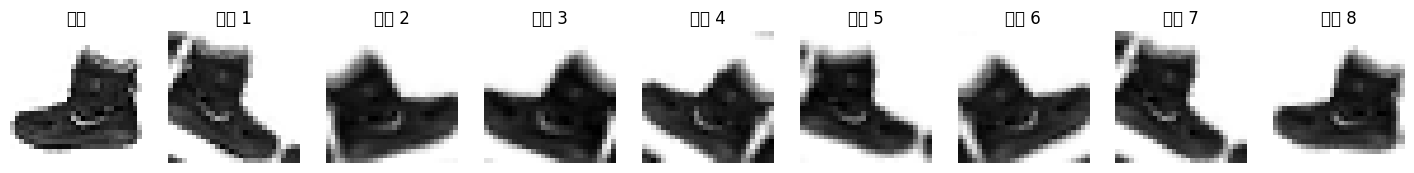

In [43]:
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

(train_input, _), _ = fashion_mnist.load_data()
sample = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0   # ankle boot 1장

fig, axs = plt.subplots(1, 9, figsize=(18, 2))
axs[0].imshow(sample[0, :, :, 0], cmap='gray_r')
axs[0].set_title("원본")
axs[0].axis('off')

for i in range(1, 9):
    augmented = data_augmentation(sample, training=True)  # training=True: 변형 적용
    axs[i].imshow(augmented[0, :, :, 0], cmap='gray_r')
    axs[i].set_title(f"증강 {i}")
    axs[i].axis('off')
plt.show()

In [44]:
# 증강된 데이터를 모델에 통합
model_aug = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,                                         # ← 이 한 줄만 추가
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax'),
])

전이학습

In [50]:
from keras.applications import MobileNetV2


In [47]:
import tensorflow as tf
from keras.datasets import cifar10

# CIFAR-10 로드 (3채널 컬러, 10클래스)
(x_train, y_train_raw), (x_test, y_test_raw) = cifar10.load_data()
y_train = y_train_raw.flatten()   # (50000, 1) → (50000,)
y_test  = y_test_raw.flatten()

# MobileNetV2 최소 입력 크기 96×96 ? CIFAR-10(32×32)을 리사이즈
x_train_r = tf.image.resize(x_train, [96, 96]) / 255.0
x_test_r  = tf.image.resize(x_test,  [96, 96]) / 255.0


In [54]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False, #top Dense 제외
    weights="imagenet" #imagenet에서 학습된 가중치 사용
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
# 레이어 갯수, 파라미터 수
len(base_model.layers), base_model.count_params()

(154, 2257984)

In [ ]:
base_model.trainable = False #False라고 하면 가중치 학습 시키지 않음 FREEZE!!!!

In [59]:
inputs = keras.Input((96, 96, 3)) # 입력층
x = base_model(inputs, training=False) # 학습 안함


In [61]:
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(10, activation='softmax')(x)
model_tl = keras.Model(inputs, x)

In [62]:
model_tl.compile(optimizer='adam',
                 loss=keras.losses.SparseCategoricalCrossentropy,
                 metrics=['accuracy'])

In [67]:
model_tl.fit(x_train_r, y_train, epochs=5, validation_split=0.2, batch_size=64)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.9895 - loss: 0.0395 - val_accuracy: 0.8533 - val_loss: 0.5589
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 169ms/step - accuracy: 0.9896 - loss: 0.0355 - val_accuracy: 0.8287 - val_loss: 0.7196
Epoch 3/5
533/625 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.9918 - loss: 0.0297

KeyboardInterrupt: 

파인튜닝

In [64]:
# 1. base_model 일부 해제
base_model.trainable = True

In [65]:
# base_model의 하위 층은 유지, 상위 30층부터 학습 허용
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"전체 레이어: {len(base_model.layers)}")
print(f"동결 레이어: {fine_tune_at}")
print(f"학습 가능 레이어: {len(base_model.layers) - fine_tune_at}")

전체 레이어: 154
동결 레이어: 124
학습 가능 레이어: 30


In [66]:
# 2. 낮은 학습률로 재컴파일 — 기본 Adam LR(1e-3)의 1/10
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    x_train_r, y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 161ms/step - accuracy: 0.8054 - loss: 0.5885 - val_accuracy: 0.7966 - val_loss: 0.5838
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9117 - loss: 0.2587 - val_accuracy: 0.8272 - val_loss: 0.5423
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 184ms/step - accuracy: 0.9538 - loss: 0.1435 - val_accuracy: 0.8378 - val_loss: 0.5168
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.9764 - loss: 0.0818 - val_accuracy: 0.8484 - val_loss: 0.5219
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.9850 - loss: 0.0541 - val_accuracy: 0.8477 - val_loss: 0.5461
